In [1]:
!pip install imbalanced-learn

In [1]:
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import matplotlib.pyplot as plt

from joblib import dump, load
from os import path
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.pyplot import *
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

In [3]:
# full dataset
#path = "swb-s3926387-personal-study"
path = r'../CIC-IDS/CSV-2023/MERGED_CSV'
all_files = glob.glob(path + "/*.csv")
li = []
for filename in all_files:
    df = pd.read_csv(filename, encoding='cp1252', index_col=None, header=0)
    li.append(df)
    print("Read Completed for ", filename)
df = pd.concat(li, axis=0, ignore_index=True)
df.describe()
df.head()
df.info()

Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged01.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged02.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged03.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged04.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged05.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged06.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged07.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged08.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged09.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged10.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged11.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged12.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged13.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged14.csv
Read Completed for  ../CIC-IDS/CSV-2023/MERGED_CSV\Merged15.csv
Read Completed for  ../CIC-IDS/CSV-2023/

c:\Users\ADMIN\anaconda3\envs\thinh\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45019243 entries, 0 to 45019242
Data columns (total 40 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Header_Length    float64
 1   Protocol Type    int64  
 2   Time_To_Live     float64
 3   Rate             float64
 4   fin_flag_number  float64
 5   syn_flag_number  float64
 6   rst_flag_number  float64
 7   psh_flag_number  float64
 8   ack_flag_number  float64
 9   ece_flag_number  float64
 10  cwr_flag_number  float64
 11  ack_count        float64
 12  syn_count        float64
 13  fin_count        float64
 14  rst_count        float64
 15  HTTP             float64
 16  HTTPS            float64
 17  DNS              float64
 18  Telnet           float64
 19  SMTP             float64
 20  SSH              float64
 21  IRC              float64
 22  TCP              float64
 23  UDP              float64
 24  DHCP             float64
 25  ARP              float64
 26  ICMP             float64
 27  IGMP      

In [4]:
print(df.columns)
print(df["Label"].value_counts())
print(df.shape)

Index(['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
       'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
       'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
       'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
       'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label'],
      dtype='object')
Label
DDOS-ICMP_FLOOD            6893259
DDOS-UDP_FLOOD             5181027
DDOS-TCP_FLOOD             4306086
DDOS-PSHACK_FLOOD          3920372
DDOS-SYN_FLOOD             3886130
DDOS-RSTFINFLOOD           3872808
DDOS-SYNONYMOUSIP_FLOOD    3445659
DOS-UDP_FLOOD              3177323
DOS-TCP_FLOOD              2558256
DOS-SYN_FLOOD              1942176
BENIGN                     1051373
MIRAI-GREETH_FLOOD          949381
MIRAI-UDPPLAIN              852695
MIRAI-GREIP_FLOOD   

In [3]:
delete_cat = ['DDOS-RSTFINFLOOD', 'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-SYN_FLOOD', 'DDOS-TCP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-TCP_FLOOD', 'RECON-OSSCAN', 'RECON-PORTSCAN']

df = df[~df['Label'].isin(delete_cat)].reset_index(drop=True)

In [6]:
# As shown in feature importances, some low importance features will be deleted
df = df.drop(columns=['SMTP', 'Telnet', 'IRC', 'cwr_flag_number', 'IGMP', 'ece_flag_number', 'DHCP', 'LLC', 'ARP', 'IPv', 'DNS', 'ICMP', 'UDP'])

Many network intrusion datasets (like CICIoT2023) contain very specific attack names (e.g., 'DDoS-UDP_Flood', 'SqlInjection'). These are too granular for efficient model training and analysis, so we group them into broader categories, such as 'DDoS', 'DoS', 'Recon', etc.

<h3> Why this is useful </h3>
    <li> Reduces label complexity (from 30+ labels to ~6–7 categories).</li>
    <li> Helps balance the dataset more evenly.</li>
    <li> Simplifies the classification problem for your ML model.</li>

<h3> Example: </h3>
<p>If your original data had this:</p>
<P>Label</p>
<ul>
    <li>DDoS-UDP_Flood</li>
    <li>DDoS-ACK_Fragmentation</li>
    <li>SqlInjection</li>
</ul>

<p>It will become:</p>
<p>Label</p>
<ul>
    <li>DDoS</li>
    <li>DDoS</li>
    <li>Web_based</li>
</ul>

In [4]:
# DDoS = ['DDOS-ACK_FRAGMENTATION',     
#         'DDOS-UDP_FLOOD',       
#         'DDOS-SLOWLORIS',               
#         'DDOS-ICMP_FLOOD',     
#         'DDOS-PSHACK_FLOOD',        
#         'DDOS-HTTP_FLOOD',              
#         'DDOS-UDP_FRAGMENTATION',         
#         'DDOS-ICMP_FRAGMENTATION']

# DoS = ['DOS-UDP_FLOOD',       
#        'DOS-HTTP_FLOOD']

# Spoofing = ['MITM-ARPSPOOFING',     
#             'DNS_SPOOFING']

# Brute_force = ['DICTIONARYBRUTEFORCE']

# Recon = ['RECON-HOSTDISCOVERY',                
#          'RECON-PINGSWEEP',         
#          'VULNERABILITYSCAN']

# Web_based = ['SQLINJECTION',        
#              'BROWSERHIJACKING',         
#              'COMMANDINJECTION',       
#              'XSS',         
#              'BACKDOOR_MALWARE',          
#              'UPLOADING_ATTACK']

# Mirai = ['MIRAI-GREETH_FLOOD',     
#          'MIRAI-UDPPLAIN',     
#          'MIRAI-GREIP_FLOOD']



DDoS = ['DDOS-ACK_FRAGMENTATION',     
        'DDOS-UDP_FLOOD',       
        'DDOS-SLOWLORIS',               
        'DDOS-ICMP_FLOOD',        
        'DDOS-RSTFINFLOOD',    
        'DDOS-PSHACK_FLOOD',        
        'DDOS-HTTP_FLOOD',              
        'DDOS-UDP_FRAGMENTATION',     
        'DDOS-TCP_FLOOD',  
        'DDOS-SYN_FLOOD',        
        'DDOS-SYNONYMOUSIP_FLOOD',    
        'DDOS-ICMP_FRAGMENTATION']

DoS = ['DOS-UDP_FLOOD',    
       'DOS-TCP_FLOOD',    
       'DOS-SYN_FLOOD',    
       'DOS-HTTP_FLOOD']

Spoofing = ['MITM-ARPSPOOFING',     
            'DNS_SPOOFING']

Brute_force = ['DICTIONARYBRUTEFORCE']

Recon = ['RECON-HOSTDISCOVERY', 
         'RECON-OSSCAN',     
         'RECON-PORTSCAN',               
         'RECON-PINGSWEEP',         
         'VULNERABILITYSCAN']

Web_based = ['SQLINJECTION',        
             'BROWSERHIJACKING',         
             'COMMANDINJECTION',       
             'XSS',         
             'BACKDOOR_MALWARE',          
             'UPLOADING_ATTACK']

Mirai = ['MIRAI-GREETH_FLOOD',     
         'MIRAI-UDPPLAIN',     
         'MIRAI-GREIP_FLOOD']




def classify_attacks(data):
    data['Label'].replace(DDoS,'DDoS',inplace=True)
    data['Label'].replace(DoS,'DoS',inplace=True)
    data['Label'].replace(Spoofing,'Spoofing',inplace=True)
    data['Label'].replace(Brute_force,'Brute_Force',inplace=True)
    data['Label'].replace(Recon,'Recon',inplace=True)
    data['Label'].replace(Web_based,'Web_based',inplace=True)
    data['Label'].replace(Mirai,'Mirai',inplace=True)
classify_attacks(df)

print(df["Label"].value_counts())
print(df.shape)

Label
DDoS           17025514
DoS             3246122
Mirai           2521731
BENIGN          1051373
Recon            488421
Spoofing         465937
Web_based         23799
Brute_Force       12522
Name: count, dtype: int64
(24835428, 40)


export csv that contain only 1 label

In [8]:
# category_counts = df["Label"].value_counts()
# category_names = category_counts.index.tolist()

# for cat in category_names:
#     csv_by_label = df[df['Label'] == cat]
#     csv_by_label.to_csv('Label CSV/{}.csv'.format(cat), index=False)

Non-numerical data is incomprehensible to machine learning modules. To avoid issues later on, the data should be arranged numerically. The answer to this problem is to convert all text values to numerical form.

<p>data_clean = df.drop_duplicates(keep='first', inplace = True)</p>
<p>data_clean = data_clean.replace([np.inf, -np.inf], np.nan, inplace=True)</p>
<p>data_clean = data_clean.dropna(inplace=True).reset_index(drop=True) </p>
<h3>AttributeError: 'NoneType' object has no attribute 'replace'</h3>
<p>The issue is that inplace=True makes the method return None, so data_clean becomes None.
<h2>Why This Matters:</h2>
<li>inplace=True means the operation modifies the original DataFrame and returns None.
<li>So doing data_clean = df.drop_duplicates(inplace=True) sets data_clean to None.

In [5]:
df.drop_duplicates(keep='first', inplace = True)
df.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
df.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
df.reset_index(drop=True, inplace=True)

print("Read {} rows.".format(len(df)))

# data_clean.columns          # This just lists the column names in the data_clean DataFrame—helpful for debugging or inspection.   
print(df.shape)
print(df['Label'].value_counts())   # Shows how many samples exist for each class (now as numbers). This is useful to check for class imbalance.

Read 12823898 rows.
(12823898, 40)
Label
DDoS           6539582
Mirai          2359183
DoS            1919696
BENIGN         1047308
Recon           486247
Spoofing        435662
Web_based        23700
Brute_Force      12520
Name: count, dtype: int64


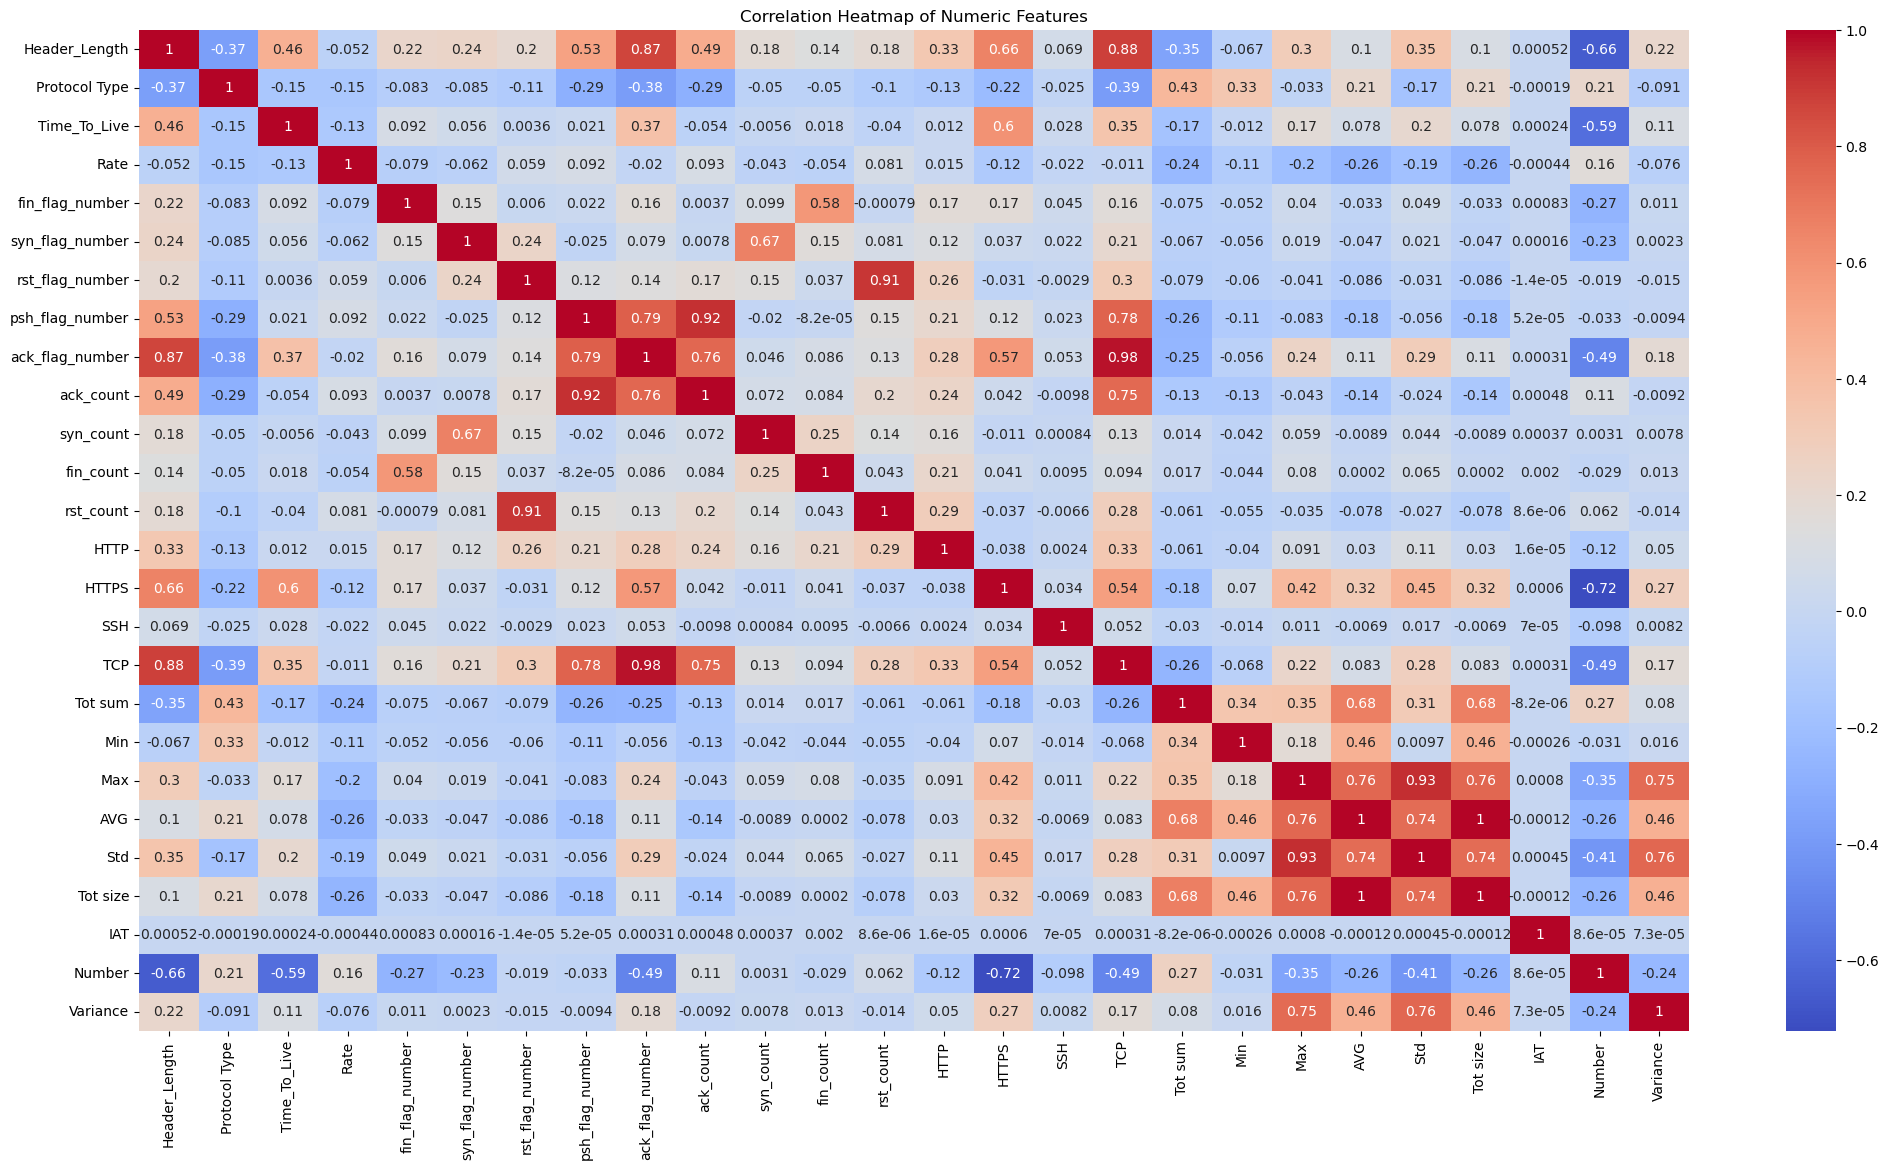

In [10]:
# Before correlation filter
# Select only numeric columns for correlation
numeric_data = df.select_dtypes(include=['number'])

plt.figure(figsize=(25, 13))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [11]:
# Delete the high corralation features
df = df.drop(columns=['fin_count', 'fin_flag_number', 'rst_count', 'rst_flag_number', 'syn_count', 'syn_flag_number', 'Number'])

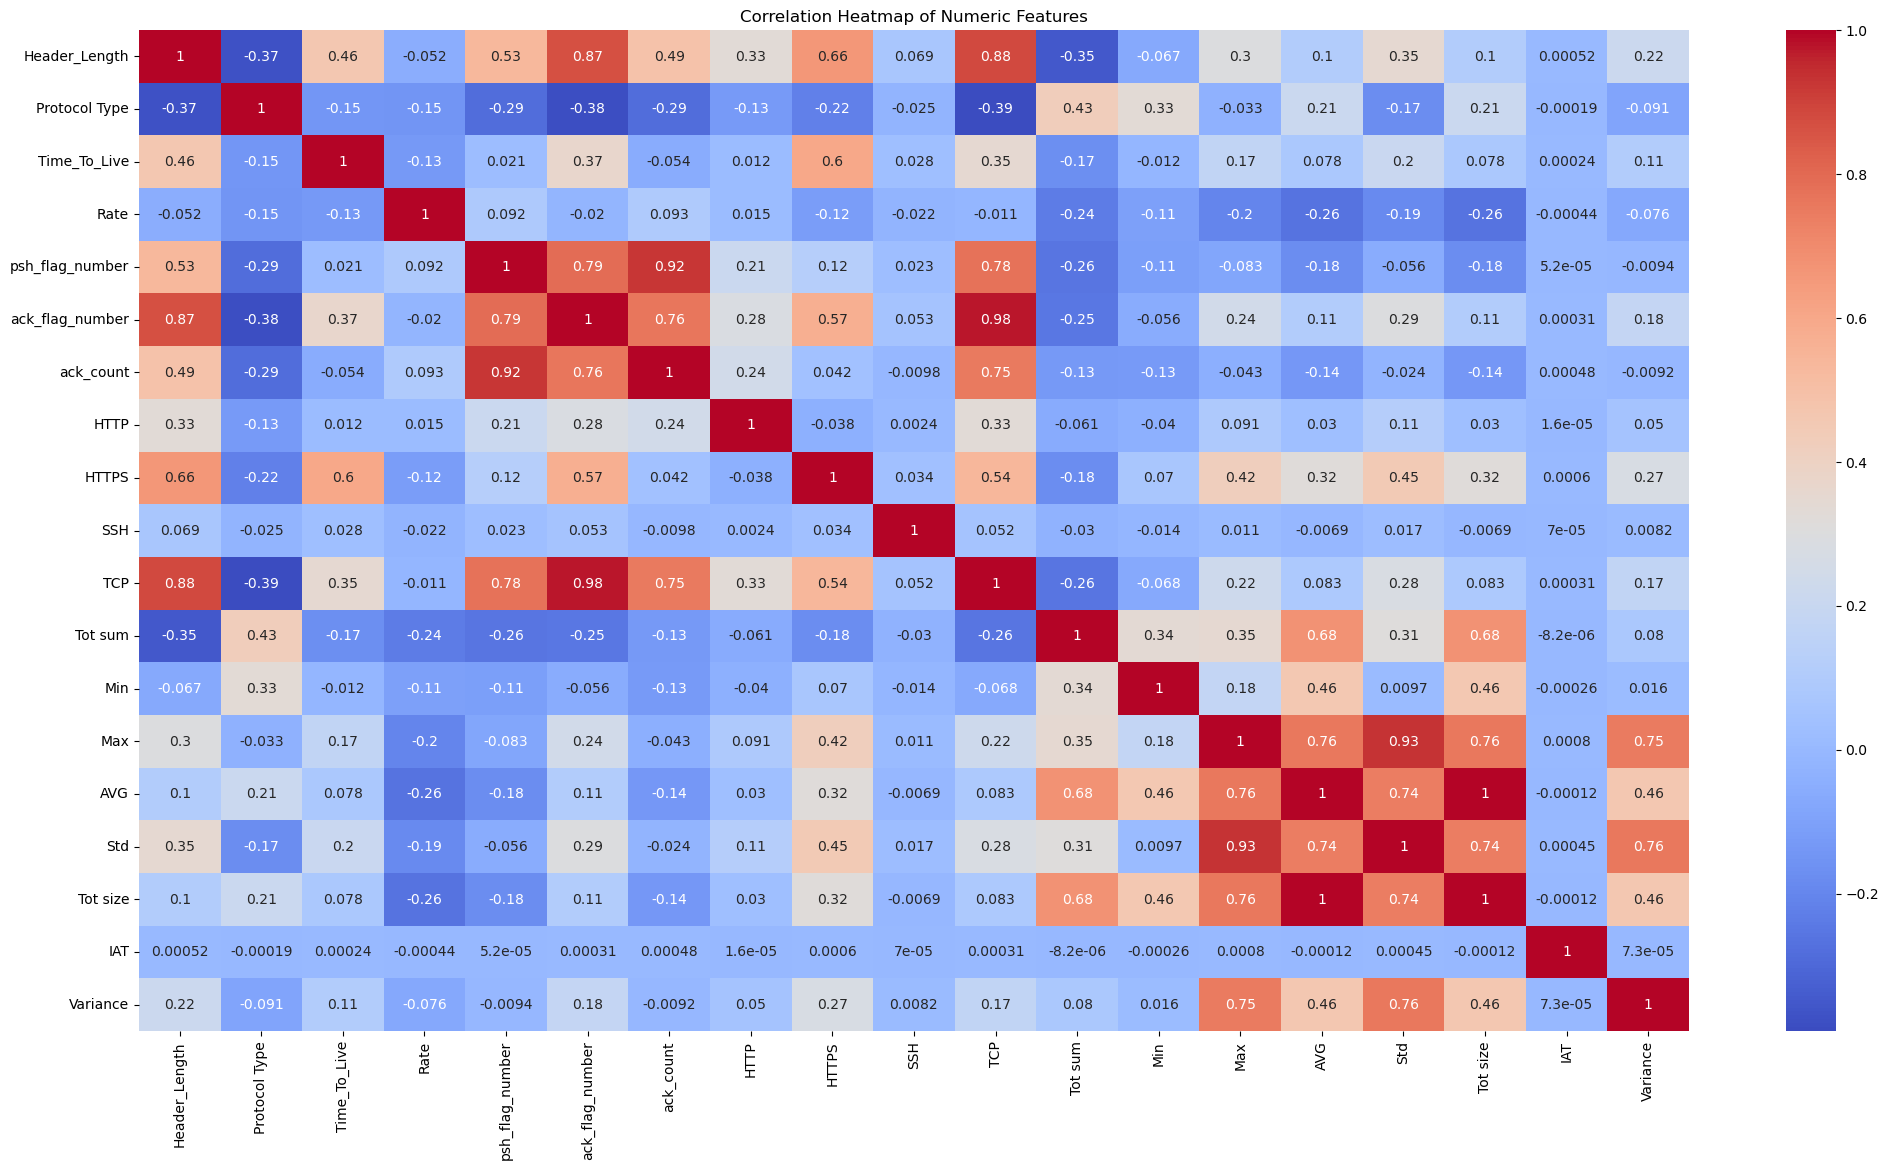

In [12]:
# After correlation filter
# Select only numeric columns for correlation
numeric_data = df.select_dtypes(include=['number'])

plt.figure(figsize=(25, 13))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [13]:
columns_name = df.drop(columns=['Label']).columns

In [14]:
# data_np = data_clean.to_numpy(dtype="float32")      # Converts the entire DataFrame into a NumPy array with float32 data type—faster and more efficient for ML model input.
# #drop inf values
# data_np = data_np[~np.isinf(data_np).any(axis=1)]   # Removes any rows that have infinite values (inf) across any column. This ensures clean numeric data for training

In [15]:
# Dataset check
# for i in range(100):
#     print(data_clean['index'][i])


In [6]:
rows = df.shape[0]
limit = round(rows*50/100) # split the dataset into 2 part: 80% for train and val; 20% to test
train_val = df[1:limit] 	

test = df[limit:rows]

In [17]:
print(train_val.shape)
# print(train_val['Label'].value_counts())

(6411373, 20)


In [18]:
# X = train_val[:, :-1] 
# Y = train_val[:, -1]

In [7]:
X = train_val.drop(columns=['Label'])
Y = train_val['Label']

In [20]:
print(Y.shape)
print(X.shape)

(6411373,)
(6411373, 19)


In [8]:
label_series = pd.Series(Y) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
sample_limit = label_series.value_counts()[2]
print(label_series.value_counts())
print(sample_limit)

Label
DDoS           3370540
Mirai          1138390
DoS             957177
BENIGN          493354
Recon           229250
Spoofing        206144
Web_based        11189
Brute_Force       5904
Name: count, dtype: int64
957177


In [9]:
# Unbalance handling

# Under sampling
# Grouped labels
undersample = RandomUnderSampler(sampling_strategy={'DDoS':sample_limit, 'Mirai':sample_limit}) # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
#                                                                                     the target undersample - in this case '2' is the name of the 'DDOS' after encoded

# Separated labels
#undersample = RandomUnderSampler(sampling_strategy={'DDOS-ICMP_FLOOD':sample_limit, 'DDOS-UDP_FLOOD':sample_limit, 'DOS-UDP_FLOOD':sample_limit, 'DDOS-PSHACK_FLOOD':sample_limit, 'BENIGN':sample_limit,'MIRAI-GREETH_FLOOD':sample_limit, 'MIRAI-UDPPLAIN':sample_limit})

X_under, y_under = undersample.fit_resample(X, Y)

# Over sampling
sm = SMOTE()
X_sm, Y_sm = sm.fit_resample(X_under, y_under)

print(Y_sm.shape)
print(X_sm.shape)

(7657416,)
(7657416, 39)


In [35]:
# Under sampling only
# undersample = RandomUnderSampler(sampling_strategy='all')   # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
#                                                             # the target undersample - in this case '2' is the name of the 'DDOS' after encoded
# X_sm, Y_sm = undersample.fit_resample(X, Y)

In [10]:
# This block is created to keep track with the under or over sampling

# labels = Y_sm.astype(int) # data_np default as float, float can't work with the inverse transform

# decoded_labels = labelencoder.inverse_transform(labels) # Inverse transform the whole array
#                                                         # inverse_transform() accepts a NumPy array, so it internally uses vectorized operations

# label_series = pd.Series(decoded_labels) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
# print(label_series.value_counts())

label_series = pd.Series(Y_sm) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
BENIGN         957177
Brute_Force    957177
DDoS           957177
DoS            957177
Mirai          957177
Recon          957177
Spoofing       957177
Web_based      957177
Name: count, dtype: int64


In [11]:
X_test = test.drop(columns=['Label'])
Y_test = test['Label']

What it does:
This scales (standardizes) your feature matrix X.
Specifically:
<ul>
    <li>StandardScaler() creates an object that standardizes the features.
    <li>Standardization means: for each feature/column in X, it will subtract the mean and divide by the standard deviation.
</ul>
Mathematically for each feature:

𝑋_scaled = (𝑋 − mean(𝑋)) / std(𝑋)
 
As a result:
<ul>
    <li>The new mean of each feature = 0.
    <li>The new standard deviation of each feature = 1.
</ul>

Why StandardScale important?
<ul>
    <li>Machine Learning algorithms (especially neural networks) work better when input features are on the same scale.
    <li>If features have very different scales (e.g., some from 0–1, some from 0–10,000), the model can struggle to converge or be biased toward features with larger numbers.
    <li>Standardization makes gradient descent faster and model training more stable.
</ul>

In simple terms:
<ul>
    <li>Before: your features might look like [50, 10000, 3.2, 0.001]
    <li>After StandardScaler: numbers become something like [0.12, 2.5, -1.0, -0.3]
    <li>Now all features are centered around 0 and have similar ranges, which helps the model learn better!
</ul>

In [13]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_sm)

In [26]:
X_test_scaled = scaler.fit_transform(X_test)

In [14]:
# Split the data set into training and testing
X_train, X_val, Y_train, Y_val = train_test_split(
    X_scaled, Y_sm, test_size=0.25, random_state=33, shuffle=True)

_features = X_sm.shape[1]  # _features stores how many input features there are (i.e., the number of columns in X).
n_classes = Y_sm.shape  # n_classes stores how many output classes there are (i.e., how many unique categories in Y after one-hot encoding).

In [15]:
print(_features)
print(n_classes)

39
(7657416,)


<h2>Random Forest<h2>

<h4>Hold-out method for Random Forest model<h4>

In [42]:
# GridSearchCV

# param_grid = {
#     'n_estimators': [50, 100, 150, 200],
#     'max_depth': [10, 15, 20, None],
#     'min_samples_split': [2, 50, 100],
#     'min_samples_leaf': [1, 10, 50]
# }

# grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring = 'f1_macro')
# grid.fit(X_train, Y_train)
# print("Best parameters:", grid.best_params_)

grid.best_params_ is a dictionary (e.g. {'n_estimators': 100, 'max_depth': 10, ...}), and passing it as a single positional argument will raise an error because RandomForestClassifier() expects keyword arguments.

You should unpack the dictionary using ** like this: RandomForestClassifier(**grid.best_params_)

In [16]:
# Train model
frst_model = RandomForestClassifier(n_estimators=100,
                                    max_depth=15,           # Limit tree depth to avoid overfitting + speed up
                                    min_samples_split=10,   # Reduce splits on small nodes
                                    min_samples_leaf=10,    # Prevent tiny leaves
                                    max_features='sqrt',    # Faster: only sqrt(features) per split
                                    n_jobs=-1,              # Use all CPU cores
                                    # verbose=10000,          # Show progress
                                    random_state=42)        # Reproducibility

frst_model.fit(X_train, Y_train)

y_pred_frst = frst_model.predict(X_val)

<h4>Validate Hold-out Model<h4>

In [17]:
# print('Accuracy score: %.2f' % accuracy_score(Y_val, y_pred_frst))
# print('Precision score: %.2f' % precision_score(Y_val, y_pred_frst, average='weighted'))
# print('Recall score: %.2f' % recall_score(Y_val, y_pred_frst, average='weighted'))
# print('F1 score: %.2f' % f1_score(Y_val, y_pred_frst, average='weighted'))

print(classification_report(Y_val, y_pred_frst))

              precision    recall  f1-score   support

      BENIGN       0.71      0.77      0.74    239286
 Brute_Force       0.84      0.76      0.80    239147
        DDoS       0.96      0.78      0.86    239263
         DoS       0.81      0.97      0.88    239505
       Mirai       1.00      1.00      1.00    238589
       Recon       0.69      0.68      0.68    238829
    Spoofing       0.92      0.87      0.89    239999
   Web_based       0.65      0.70      0.67    239736

    accuracy                           0.81   1914354
   macro avg       0.82      0.81      0.82   1914354
weighted avg       0.82      0.81      0.82   1914354



In [ ]:
# Confusion matrix
cm = confusion_matrix(Y_val, y_pred_frst)

# Extract sorted unique labels from Y_val
class_labels = sorted(Y_val.unique())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(xticks_rotation=45)

In [ ]:
# Check feature importance
feat_importances = pd.Series(frst_model.feature_importances_, index=columns_name)
top_features = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top 20 Feature Importances in Random Forest")
plt.show()

In [ ]:
for i in range(50):
    sample = X_test.iloc[[i]]  # Make it 2D by using double brackets
    pred = frst_model.predict(sample)
    actual = Y_test.iloc[i]

    print(f"Sample {i}: Predicted = {pred[0]}, Actual = {actual}")


In [18]:
# Save the model
with open('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Models/CIC_models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(frst_model, f)

In [ ]:
# Load the model
with open('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Models/CIC_models/random_forest_model.pkl', 'rb') as f:
    frst_model = pickle.load(f)

In [31]:
test_label_series = pd.Series(Y_test) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
test_sample_limit = test_label_series.value_counts()[4]
print(test_label_series.value_counts())
print(test_sample_limit)

Label
DDoS           3168828
Mirai          1220821
DoS             962111
BENIGN          553965
Recon           256998
Spoofing        229522
Web_based        12512
Brute_Force       6616
Name: count, dtype: int64
256998


In [32]:
# Under sampling
test_undersample = RandomUnderSampler(sampling_strategy={'DDoS':test_sample_limit, 'DoS':test_sample_limit, 'Mirai':test_sample_limit, 'BENIGN':test_sample_limit}) # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
                                                                                    # the target undersample - in this case '2' is the name of the 'DDOS' after encoded

# Separated labels
#test_undersample = RandomUnderSampler(sampling_strategy={'DDOS-ICMP_FLOOD':sample_limit, 'DDOS-UDP_FLOOD':sample_limit, 'DOS-UDP_FLOOD':sample_limit, 'DDOS-PSHACK_FLOOD':sample_limit, 'BENIGN':sample_limit,'MIRAI-GREETH_FLOOD':sample_limit, 'MIRAI-UDPPLAIN':sample_limit})

X_test_under, y_test_under = test_undersample.fit_resample(X_test_scaled, Y_test)

# Over sampling
test_sm = SMOTE()
X_test_sm, Y_test_sm = test_sm.fit_resample(X_test_under, y_test_under)

print(Y_test_sm.shape)
print(X_test_sm.shape)

(2055984,)
(2055984, 19)


In [33]:
test_label_series = pd.Series(Y_test_sm) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(test_label_series.value_counts())

Label
BENIGN         256998
Brute_Force    256998
DDoS           256998
DoS            256998
Mirai          256998
Recon          256998
Spoofing       256998
Web_based      256998
Name: count, dtype: int64


In [34]:
test_pred = frst_model.predict(X_test_sm)
print(classification_report(Y_test_sm, test_pred))

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.5s
[Parallel(n_jobs=20)]: Done   2 tasks      | elapsed:    0.5s
[Parallel(n_jobs=20)]: Done   3 tasks      | elapsed:    0.5s
[Parallel(n_jobs=20)]: Done   4 tasks      | elapsed:    0.5s
[Parallel(n_jobs=20)]: Done   5 tasks      | elapsed:    0.6s
[Parallel(n_jobs=20)]: Done   6 tasks      | elapsed:    0.6s
[Parallel(n_jobs=20)]: Done   7 tasks      | elapsed:    0.6s
[Parallel(n_jobs=20)]: Done   8 tasks      | elapsed:    0.7s
[Parallel(n_jobs=20)]: Done   9 tasks      | elapsed:    0.7s
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.7s
[Parallel(n_jobs=20)]: Done  11 tasks      | elapsed:    0.8s
[Parallel(n_jobs=20)]: Done  12 tasks      | elapsed:    0.8s
[Parallel(n_jobs=20)]: Done  13 tasks      | elapsed:    0.8s
[Parallel(n_jobs=20)]: Done  14 tasks      | elapsed:    0.9s
[Parallel(n_jobs=20)]: Done  15 tasks      | elaps

<h4>KFold method for Random Forest model<h4>

In [ ]:
folds = 5  # Define the number of folds for K-fold cross-validation

kf = KFold(n_splits=folds, shuffle=True, random_state=42)  # Initialize the KFold object

for train_index, test_index in kf.split(X_train):
    # Split the dataset into training and testing sets for this fold
    X_frst_train_fold, X_frst_test_fold = X_train[train_index], X_train[test_index]
    y_frst_train_fold, y_frst_test_fold = Y_train.iloc[train_index], Y_train.iloc[test_index]
    
    # Define the model
    frst_model_fold = RandomForestClassifier(n_estimators=100, max_depth=30, min_samples_split=15, min_samples_leaf=15, max_features='sqrt', n_jobs=-1, random_state=42)
    
    # Train the model on the training data
    frst_model_fold.fit(X_frst_train_fold, y_frst_train_fold)

    # Make predictions on the test data
    y_frst_pred_fold = frst_model_fold.predict(X_frst_test_fold)

    # Calculate score for this fold
    print(classification_report(y_frst_test_fold, y_frst_pred_fold))
    print("\n")

In [ ]:
frst_model_fold.fit(X_train, Y_train)

y_pred_frst_model_fold = frst_model_fold.predict(X_val)

In [ ]:
print(classification_report(Y_val, y_pred_frst_model_fold))